# Project 2: Exploratory Data Analysis (EDA) 🔍
**DecodeLabs | Industrial Training Kit | Batch 2026**

**Goal:** Analyze the clean e-commerce dataset to uncover patterns, trends, and outliers.

**Dataset:** ecommerce_clean.csv (output from Project 1)


## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries imported successfully ✅')

Libraries imported successfully ✅


## Step 2: Load Clean Dataset

In [2]:
df = pd.read_csv('../project-1-data-cleaning/ecommerce_clean.csv', parse_dates=['Date'])

print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (1177, 14)

First 5 rows:


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## Step 3: Basic Statistics (Five-Number Summary)

In [3]:
print('=== DESCRIPTIVE STATISTICS ===')
df[['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']].describe().round(2)

=== DESCRIPTIVE STATISTICS ===


,Quantity,UnitPrice,TotalPrice,ItemsInCart
count,1177.00,1177.00,1177.00,1177.00
mean,2.94,357.85,1054.96,5.47
std,1.41,197.28,819.18,2.28
min,1.00,11.39,11.39,1.00
25%,2.00,186.41,410.60,4.00
50%,3.00,367.75,824.25,5.00
75%,4.00,524.26,1582.00,7.00
max,5.00,699.93,3456.40,10.00


In [4]:
print('=== KEY METRICS ===')
print(f'Total Revenue:       ${df["TotalPrice"].sum():,.2f}')
print(f'Average Order Value: ${df["TotalPrice"].mean():,.2f}')
print(f'Median Order Value:  ${df["TotalPrice"].median():,.2f}')
print(f'Total Orders:        {len(df):,}')
print(f'Unique Customers:    {df["CustomerID"].nunique():,}')
print(f'Unique Products:     {df["Product"].nunique():,}')

=== KEY METRICS ===
Total Revenue:       $1,241,687.02
Average Order Value: $1,054.96
Median Order Value:  $824.25
Total Orders:        1,177
Unique Customers:    1,165
Unique Products:     7


## Step 4: Distribution Analysis

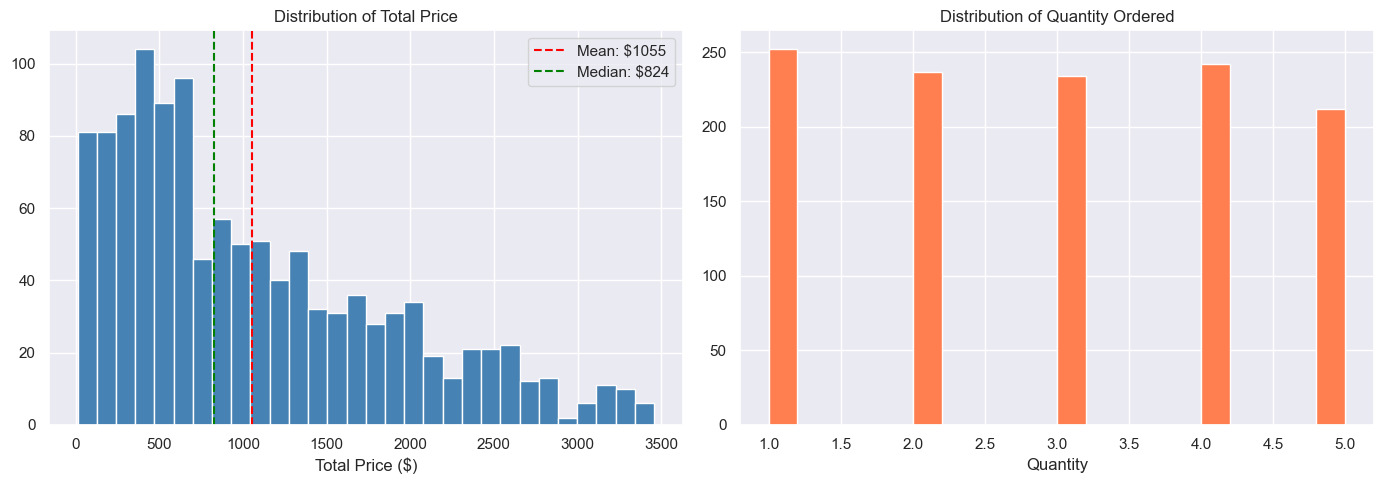

✅ Chart saved as distribution_analysis.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TotalPrice distribution
axes[0].hist(df['TotalPrice'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(df['TotalPrice'].mean(), color='red', linestyle='--', label=f'Mean: ${df["TotalPrice"].mean():.0f}')
axes[0].axvline(df['TotalPrice'].median(), color='green', linestyle='--', label=f'Median: ${df["TotalPrice"].median():.0f}')
axes[0].set_title('Distribution of Total Price')
axes[0].set_xlabel('Total Price ($)')
axes[0].legend()

# Quantity distribution
axes[1].hist(df['Quantity'], bins=20, color='coral', edgecolor='white')
axes[1].set_title('Distribution of Quantity Ordered')
axes[1].set_xlabel('Quantity')

plt.tight_layout()
plt.savefig('distribution_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as distribution_analysis.png')

## Step 5: Outlier Detection (IQR Method)

Q1: $410.60
Q3: $1582.00
IQR: $1171.40
Lower Bound: $-1346.50
Upper Bound: $3339.10

Outliers detected: 6


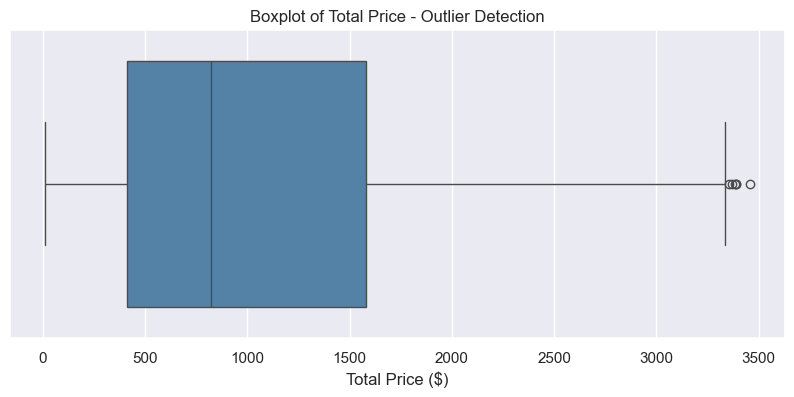

✅ Chart saved as outlier_detection.png


In [6]:
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['TotalPrice'] < lower_bound) | (df['TotalPrice'] > upper_bound)]

print(f'Q1: ${Q1:.2f}')
print(f'Q3: ${Q3:.2f}')
print(f'IQR: ${IQR:.2f}')
print(f'Lower Bound: ${lower_bound:.2f}')
print(f'Upper Bound: ${upper_bound:.2f}')
print(f'\nOutliers detected: {len(outliers)}')

# Boxplot
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['TotalPrice'], color='steelblue')
plt.title('Boxplot of Total Price - Outlier Detection')
plt.xlabel('Total Price ($)')
plt.savefig('outlier_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as outlier_detection.png')

## Step 6: Trend Analysis - Sales Over Time

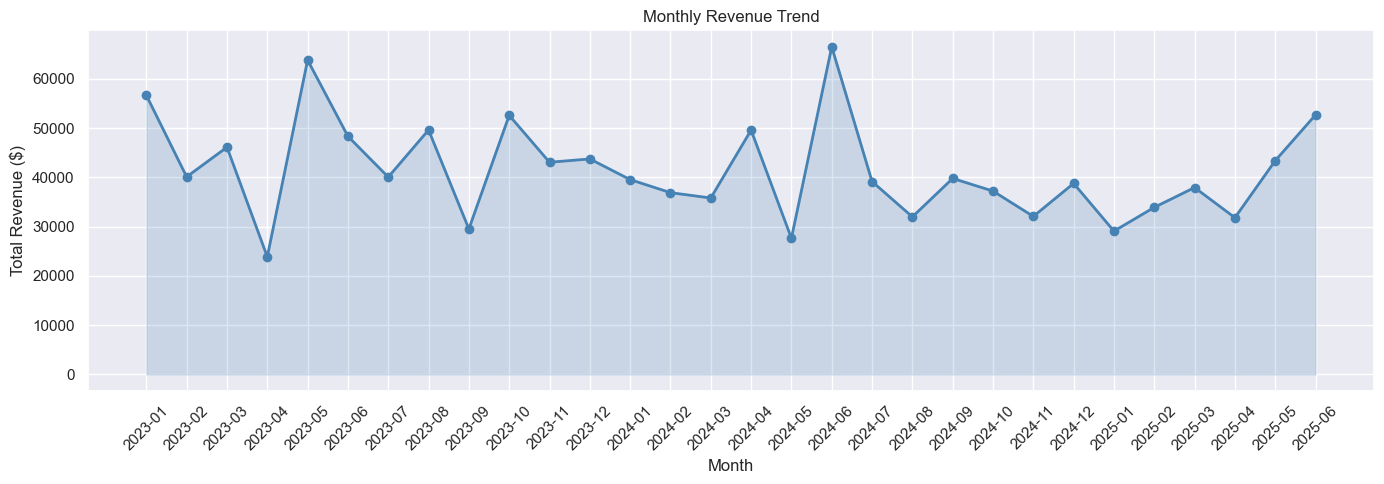

✅ Chart saved as monthly_trend.png


In [7]:
df['Month'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['TotalPrice'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['Month'], monthly_sales['TotalPrice'], marker='o', color='steelblue', linewidth=2)
plt.fill_between(range(len(monthly_sales)), monthly_sales['TotalPrice'], alpha=0.2, color='steelblue')
plt.xticks(range(len(monthly_sales)), monthly_sales['Month'], rotation=45)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as monthly_trend.png')

## Step 7: Product Performance Analysis

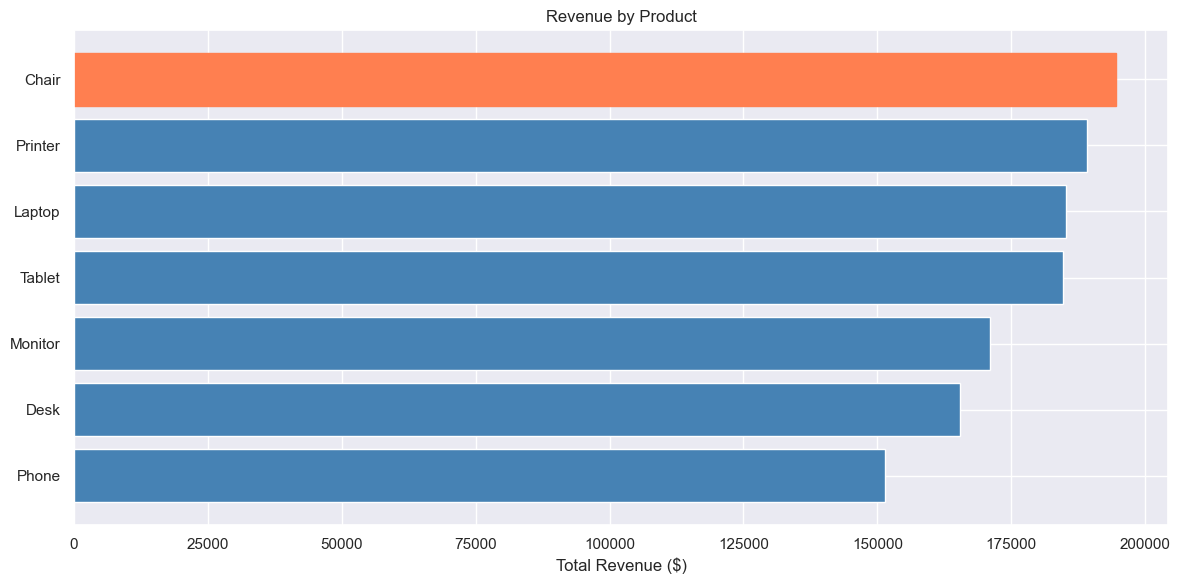

Top 3 Products by Revenue:
Product
Laptop     185174.19
Printer    189214.58
Chair      194569.15


In [8]:
product_revenue = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=True)

plt.figure(figsize=(12, 6))
bars = plt.barh(product_revenue.index, product_revenue.values, color='steelblue')
bars[-1].set_color('coral')  # Highlight top product
plt.title('Revenue by Product')
plt.xlabel('Total Revenue ($)')
plt.tight_layout()
plt.savefig('product_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 3 Products by Revenue:')
print(product_revenue.tail(3).to_string())

## Step 8: Order Status & Payment Analysis

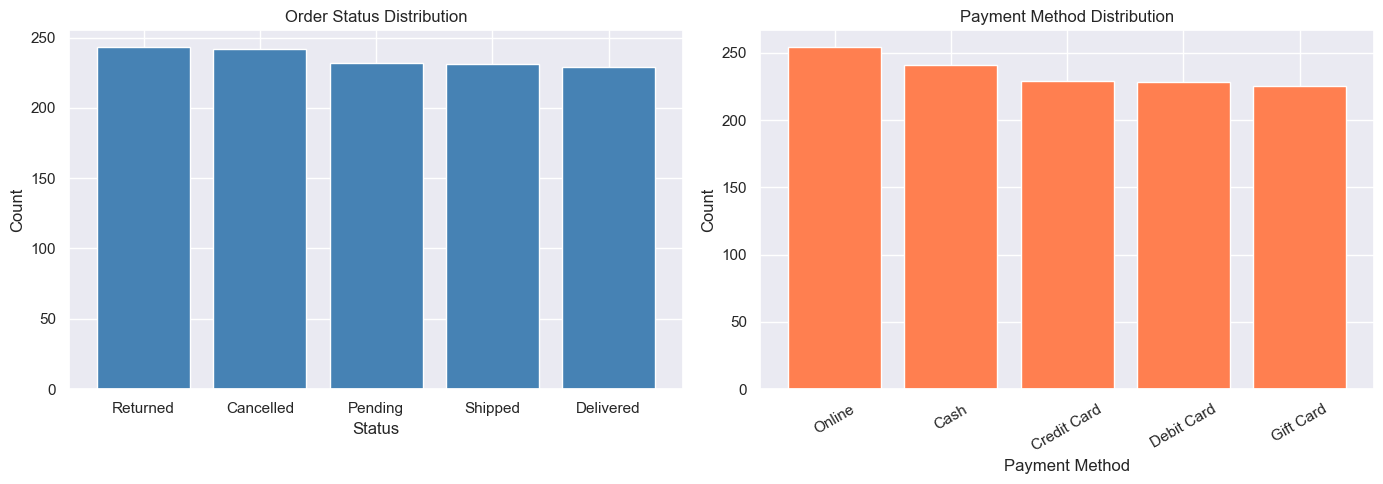

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Order Status
status_counts = df['OrderStatus'].value_counts()
axes[0].bar(status_counts.index, status_counts.values, color='steelblue')
axes[0].set_title('Order Status Distribution')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Count')

# Payment Method
payment_counts = df['PaymentMethod'].value_counts()
axes[1].bar(payment_counts.index, payment_counts.values, color='coral')
axes[1].set_title('Payment Method Distribution')
axes[1].set_xlabel('Payment Method')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('status_payment.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9: Correlation Analysis

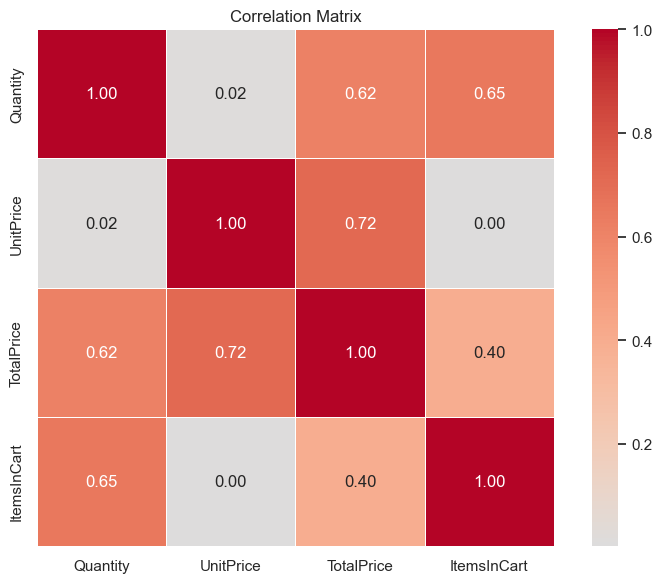

✅ Chart saved as correlation_matrix.png


In [10]:
corr_matrix = df[['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as correlation_matrix.png')

## Step 10: Executive Summary - Key Findings

In [11]:
top_product = df.groupby('Product')['TotalPrice'].sum().idxmax()
top_payment = df['PaymentMethod'].value_counts().idxmax()
top_status = df['OrderStatus'].value_counts().idxmax()

print('=' * 50)
print('       EXECUTIVE SUMMARY - EDA FINDINGS')
print('=' * 50)
print(f'\n📊 DATASET OVERVIEW')
print(f'   Total Orders:        {len(df):,}')
print(f'   Total Revenue:       ${df["TotalPrice"].sum():,.2f}')
print(f'   Unique Customers:    {df["CustomerID"].nunique():,}')

print(f'\n📈 KEY FINDINGS')
print(f'   Top Product:         {top_product}')
print(f'   Top Payment Method:  {top_payment}')
print(f'   Most Common Status:  {top_status}')
print(f'   Outliers Detected:   {len(outliers)} high-value orders')

print(f'\n💡 BUSINESS INSIGHT')
print(f'   Mean > Median in TotalPrice → Right-skewed distribution')
print(f'   Recommendation: Use Median for pricing strategy, not Mean')
print('=' * 50)

       EXECUTIVE SUMMARY - EDA FINDINGS

📊 DATASET OVERVIEW
   Total Orders:        1,177
   Total Revenue:       $1,241,687.02
   Unique Customers:    1,165

📈 KEY FINDINGS
   Top Product:         Chair
   Top Payment Method:  Online
   Most Common Status:  Returned
   Outliers Detected:   6 high-value orders

💡 BUSINESS INSIGHT
   Mean > Median in TotalPrice → Right-skewed distribution
   Recommendation: Use Median for pricing strategy, not Mean
